#  Classification avec des images réelles: dogs vs cats


Le dataset complet provient d'une compétition Kaggle: https://www.kaggle.com/c/dogs-vs-cats

Le dataset en question contient 2 folders: dogs - cats

Soit un total de 2000 images.

L'objectif est de capitaliser sur les notions du cours pour développer un réseau CNN qui arrive à prédire avec la meilleure performance possible les images de chiens et de chats.

Ce notebook va permettre de structurer l'approche et la construction du modèle.

### Livrables à remettre: 

#### 1 - Ce notebook rempli avec les outputs visibles
#### 2 - Le lien URL de votre application web en section 12

## 1- Importer des librairies pertinentes:

In [5]:
# Imports des librairies
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Configuration
import warnings
warnings.filterwarnings('ignore')
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## 2- Localiser le path où se trouvent toutes les images

In [3]:
# Define a variable as the directory path
my_data_dir = 'data_cats_and_dogs'

### 2.1 - Vérifier que la commande ci-dessous retourne ['train', 'validation']

In [6]:
os.listdir(my_data_dir)

['train', 'validation']

### 2.2 - Définir les variables train_path et val_path:

In [7]:
# train and test paths (\ for windows, / for mac)
train_path = os.path.join(my_data_dir, 'train')
test_path = os.path.join(my_data_dir, 'validation')

### 2.3 - Print le nombre d'images pour chaque class (cats & dogs) dans le dossier train et validation:

In [8]:
# Vérifier le nombre d'images de chaque classe pour le train_path et val_path
print("=== Train Set ===")
print(f"Cats: {len(os.listdir(os.path.join(train_path, 'cats')))} images")
print(f"Dogs: {len(os.listdir(os.path.join(train_path, 'dogs')))} images")

print("\n=== Validation Set ===")
print(f"Cats: {len(os.listdir(os.path.join(test_path, 'cats')))} images")
print(f"Dogs: {len(os.listdir(os.path.join(test_path, 'dogs')))} images")

# Vérifier que vous avez bien 2000 images au total !
total = (len(os.listdir(os.path.join(train_path, 'cats'))) + 
         len(os.listdir(os.path.join(train_path, 'dogs'))) +
         len(os.listdir(os.path.join(test_path, 'cats'))) +
         len(os.listdir(os.path.join(test_path, 'dogs'))))
print(f"\n=== Total: {total} images ===")

=== Train Set ===
Cats: 998 images
Dogs: 998 images

=== Validation Set ===
Cats: 500 images
Dogs: 500 images

=== Total: 2996 images ===


## 3) Analyse d'exemples d'images dogs and cats

### 3.1 - Choisir au hasard une image de dog dans le train_path

In [9]:
# Choisir au hasard une image de dog dans le train_path
dogs_dir = os.path.join(train_path, 'dogs')
random_dog = random.choice(os.listdir(dogs_dir))
dog_path = os.path.join(dogs_dir, random_dog)
print(f"Image sélectionnée: {dog_path}")

Image sélectionnée: data_cats_and_dogs\train\dogs\dog.679.jpg


### 3.2 - Transformer cette image en numpy array

In [10]:
# Transformer cette image en numpy array
dog_img = load_img(dog_path)
dog_array = img_to_array(dog_img)
print(f"Type: {type(dog_array)}")

Type: <class 'numpy.ndarray'>


### 3.3 - Vérifier les dimensions de cette image

In [11]:
# Vérifier les dimensions de cette image
print(f"Shape: {dog_array.shape}")
print(f"Hauteur: {dog_array.shape[0]} pixels")
print(f"Largeur: {dog_array.shape[1]} pixels")
print(f"Canaux (RGB): {dog_array.shape[2]}")

Shape: (311, 468, 3)
Hauteur: 311 pixels
Largeur: 468 pixels
Canaux (RGB): 3


### 3.4 -Plot cette image via 'imshow'

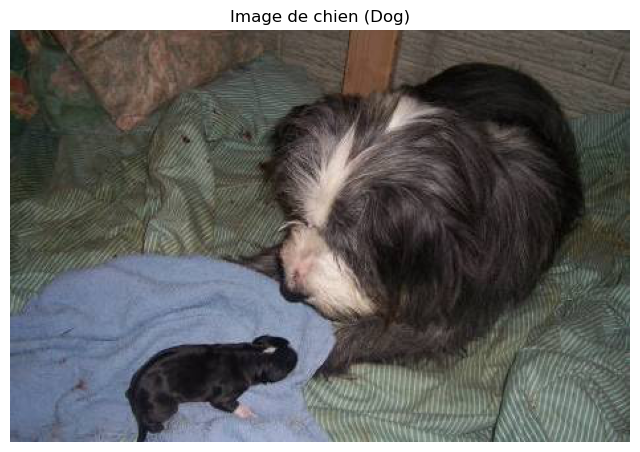

In [12]:
# Plot cette image via 'imshow'
plt.figure(figsize=(8, 6))
plt.imshow(dog_array.astype('uint8'))
plt.title('Image de chien (Dog)')
plt.axis('off')
plt.show()

### 3.5 - Refaire le même travail avec l'image d'un cat depuis le dossier train 

Image: data_cats_and_dogs\train\cats\cat.651.jpg
Shape: (290, 500, 3)


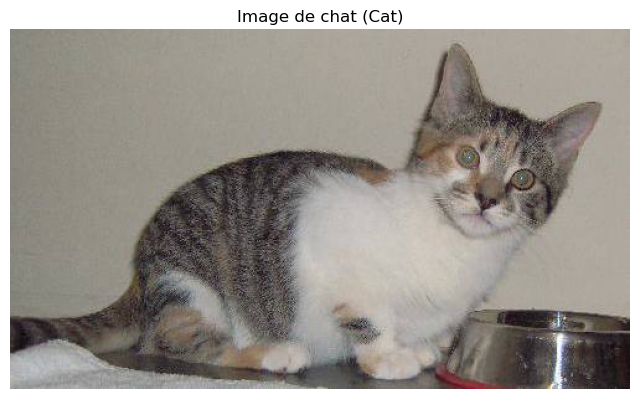

In [13]:
# Refaire le même travail avec l'image d'un cat depuis le dossier train
cats_dir = os.path.join(train_path, 'cats')
random_cat = random.choice(os.listdir(cats_dir))
cat_path = os.path.join(cats_dir, random_cat)

cat_img = load_img(cat_path)
cat_array = img_to_array(cat_img)

print(f"Image: {cat_path}")
print(f"Shape: {cat_array.shape}")

plt.figure(figsize=(8, 6))
plt.imshow(cat_array.astype('uint8'))
plt.title('Image de chat (Cat)')
plt.axis('off')
plt.show()

## 4) Créer un ImageDataGenerator qui effectue un retraitement "pertinent" de ces images:

In [14]:
# Paramètres pour l'image generator
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

In [15]:
# Créer un ImageDataGenerator avec data augmentation pour le training
image_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generator pour la validation (sans augmentation, juste rescaling)
val_image_generator = ImageDataGenerator(rescale=1./255)

## 5) Construire un modèle CNN from scratch pour la classification binaire de ces images:


**- Utiliser à minima les types layers suivants: Conv2D, MaxPooling2D, Dense.**

**- Utiliser également la technique du Dropout.**

**- Prendre un input_shape arbitraire fixe et approprié**

**- Print le model summary**

**- Ne pas hésiter à ajouter des techniques ou des méthodes sur les données ou le modèle pour améliorer la performance !**

**L'objectif est de maximiser l'accuracy sur les données de test**

In [16]:
# Afficher un résumé des données
print("***Résumé du Dataset ***")
print(f"Images d'entraînement: {len(os.listdir(os.path.join(train_path, 'cats'))) + len(os.listdir(os.path.join(train_path, 'dogs')))}")
print(f"Images de validation: {len(os.listdir(os.path.join(test_path, 'cats'))) + len(os.listdir(os.path.join(test_path, 'dogs')))}")
print(f"Taille des images: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"Batch size: {BATCH_SIZE}")

***Résumé du Dataset ***
Images d'entraînement: 1996
Images de validation: 1000
Taille des images: 150x150
Batch size: 32


In [17]:
# Create the CNN model from scratch
model = Sequential([
    # 1st convolutional block
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2, 2),
    
    # 2nd convolutional block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # 3rd convolutional block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # 4th convolutional block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Flatten and Dense layers
    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

In [18]:
# Compiler le modèle
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Afficher le résumé du modèle
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 15, 15, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,211,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

### 5.2 Créer une instance de EarlyStopping

In [19]:
# Créer une instance de EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

### 5.3 Créer un generator pour le train et validation set: 

In [20]:
# Create the train_image_generator
train_image_gen = image_generator.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

Found 1996 images belonging to 2 classes.


In [21]:
# Create the validation_image_generator
val_image_gen = val_image_generator.flow_from_directory(
    test_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False  # Important pour l'évaluation
)

Found 1000 images belonging to 2 classes.


In [22]:
# verify the classes dictionary (1 is dog or cat ?)
print("Classes mapping:")
print(train_image_gen.class_indices)
print("\n0 = Cat, 1 = Dog")

Classes mapping:
{'cats': 0, 'dogs': 1}

0 = Cat, 1 = Dog


### 5.3 Entrainer le modèle à partir du train_image_generator et utiliser le EarlyStopping

In [25]:
# Entrainer le modèle - suivre la loss, accuracy, val_loss et val_accuracy
EPOCHS = 30

history = model.fit(
    train_image_gen,
    epochs=EPOCHS,
    validation_data=val_image_gen,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.7690 - loss: 0.4952 - val_accuracy: 0.7370 - val_loss: 0.5332
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.7635 - loss: 0.5003 - val_accuracy: 0.7370 - val_loss: 0.5354
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.7705 - loss: 0.4830 - val_accuracy: 0.7840 - val_loss: 0.4689
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.7796 - loss: 0.4766 - val_accuracy: 0.7850 - val_loss: 0.4421
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.7841 - loss: 0.4680 - val_accuracy: 0.7940 - val_loss: 0.4653
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.7826 - loss: 0.4579 - val_accuracy: 0.7800 - val_loss: 0.4695
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.7871 - loss: 0.4605 - val_accuracy: 0.8030 - val_loss: 0.4456
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.7791 - loss: 0.4590 - val_accuracy: 0.7970 - val_loss

## 8) Evaluation du modèle

### 8.1 Sauvegarder les losses dans un dataframe

In [26]:
# Sauvegarder les losses dans un dataframe
losses_df = pd.DataFrame(history.history)
losses_df.head(10)

,accuracy,loss,val_accuracy,val_loss
0,0.769038,0.495229,0.737,0.533228
1,0.763527,0.500267,0.737,0.535358
2,0.770541,0.482965,0.784,0.468920
3,0.779559,0.476600,0.785,0.442126
4,0.784068,0.468020,0.794,0.465281
5,0.782565,0.457916,0.780,0.469516
6,0.787074,0.460545,0.803,0.445570
7,0.779058,0.459030,0.797,0.442979
8,0.796092,0.438308,0.749,0.512885


### 8.2 Plot le training et validation loss 

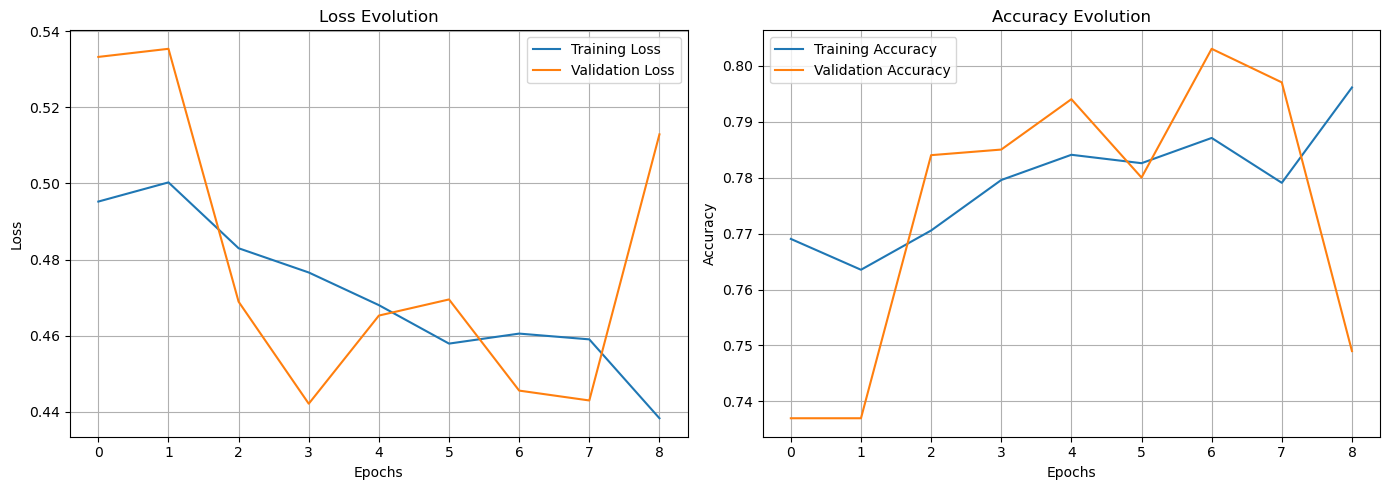

In [27]:
# Plot le training et validation loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(losses_df['loss'], label='Training Loss')
axes[0].plot(losses_df['val_loss'], label='Validation Loss')
axes[0].set_title('Loss Evolution')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(losses_df['accuracy'], label='Training Accuracy')
axes[1].plot(losses_df['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy Evolution')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 8.3 Calculer les probabilités pour le validation image generator 

In [28]:
# Calculer les probabilités pour le validation image generator
val_image_gen.reset()
y_pred_proba = model.predict(val_image_gen, verbose=1)
y_pred_proba[:10]

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 373ms/step


array([[0.70117986],
       [0.44755292],
       [0.43815875],
       [0.00980688],
       [0.6025152 ],
       [0.19543278],
       [0.51163363],
       [0.08376075],
       [0.16270785],
       [0.34900165]], dtype=float32)

### 8.4 Transformer ces probabilités en classes en prenant un threshold de 0.5

In [29]:
# Transformer ces probabilités en classes en prenant un threshold de 0.5
y_pred_class = (y_pred_proba > 0.5).astype(int).flatten()
print(f"Prédictions: {y_pred_class[:20]}")

Prédictions: [1 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0]


### 8.5 Récupérer le vecteur des true labels à partir du validation image generator

In [30]:
# Récupérer le vecteur des true labels à partir du validation image generator
y_test = val_image_gen.classes
print(f"True labels: {y_test[:20]}")

True labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### 8.6 Afficher le classification report et la matrice de confusion

=== Classification Report ===

              precision    recall  f1-score   support

         Cat       0.78      0.80      0.79       500
         Dog       0.79      0.77      0.78       500

    accuracy                           0.79      1000
   macro avg       0.79      0.79      0.78      1000
weighted avg       0.79      0.79      0.78      1000



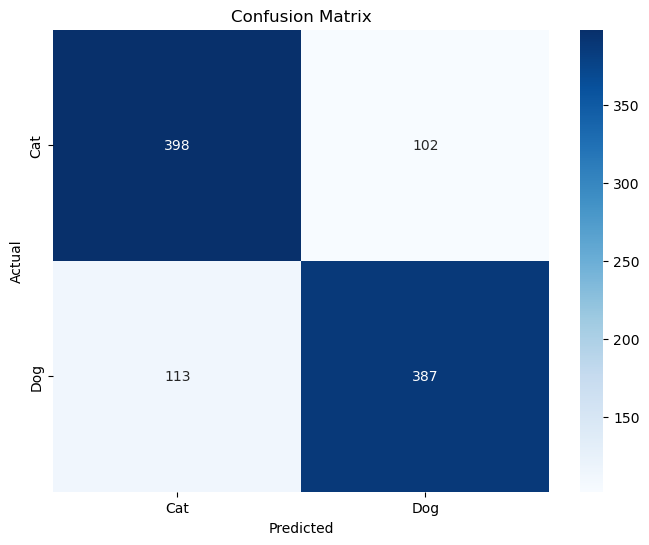

In [31]:
# Afficher le classification report et la matrice de confusion
print("=== Classification Report ===\n")
print(classification_report(y_test, y_pred_class, target_names=['Cat', 'Dog']))

# Matrice de confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 8.7 KPI final: quel est l'accuracy du model sur les données de test ? Etes-vous satisfaits de la performance de votre modèle ?

In [32]:
# KPI final: quel est l'accuracy du model sur les données de test ?
accuracy = accuracy_score(y_test, y_pred_class)
print(f"=== Accuracy sur les données de validation: {accuracy * 100:.2f}% ===")

=== Accuracy sur les données de validation: 78.50% ===


In [33]:
# Évaluation de la satisfaction
print("Analyse de la performance du modèle CNN from scratch:")
if accuracy >= 0.85:
    print("Excellente performance! Le modèle généralise bien.")
elif accuracy >= 0.75:
    print("Bonne performance, mais il y a de la marge d'amélioration.")
else:
    print("Performance à améliorer. Le transfer learning pourrait aider.")

Analyse de la performance du modèle CNN from scratch:
Bonne performance, mais il y a de la marge d'amélioration.


# 9) Prédictions sur des cas particuliers

### 9.1 Afficher quelques images des données de test où le modèle s'est trompé.

In [34]:
# Trouver les indices des images mal classifiées
misclassified_indices = np.where(y_test != y_pred_class)[0]
print(f"Nombre d'images mal classifiées: {len(misclassified_indices)}")

Nombre d'images mal classifiées: 215


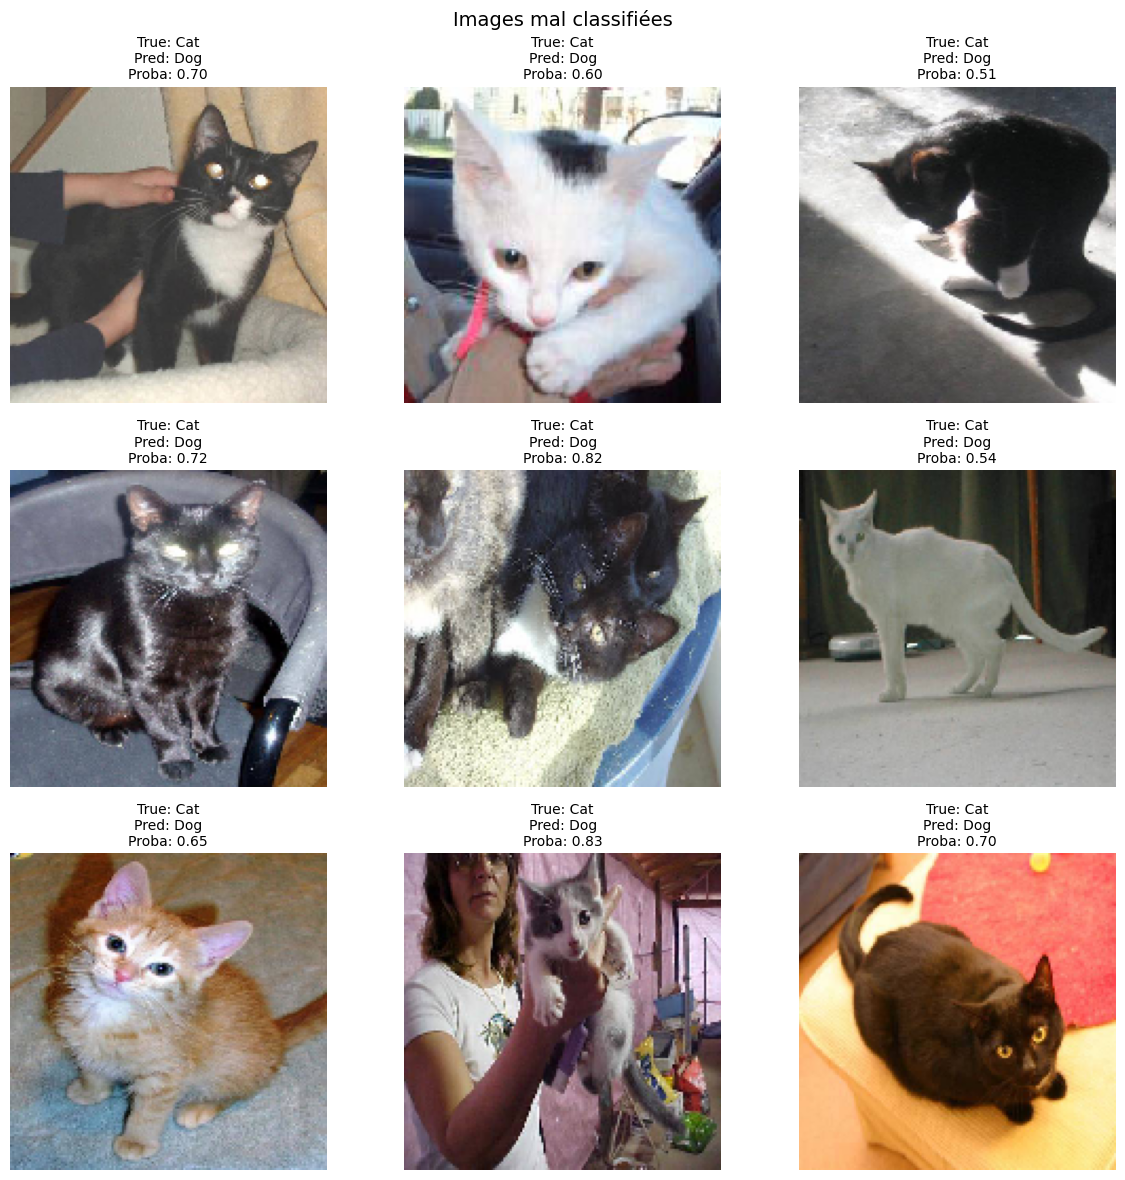

In [35]:
# Afficher quelques images des données de test où le modèle s'est trompé
filenames = val_image_gen.filenames
class_names = {0: 'Cat', 1: 'Dog'}

# Afficher les 9 premières erreurs
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, idx in enumerate(misclassified_indices[:9]):
    img_path = os.path.join(test_path, filenames[idx])
    img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    axes[i].imshow(img)
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred_class[idx]]
    prob = y_pred_proba[idx][0]
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nProba: {prob:.2f}', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Images mal classifiées', fontsize=14)
plt.tight_layout()
plt.show()

In [36]:
# Analyser les erreurs par classe
cats_misclassified = sum(1 for idx in misclassified_indices if y_test[idx] == 0)
dogs_misclassified = sum(1 for idx in misclassified_indices if y_test[idx] == 1)

print(f"Chats mal classifiés comme chiens: {cats_misclassified}")
print(f"Chiens mal classifiés comme chats: {dogs_misclassified}")

Chats mal classifiés comme chiens: 102
Chiens mal classifiés comme chats: 113


### 9.2 Ces images ont-elles des patterns en commun ?

In [38]:
# Ces images ont-elles des patterns en commun ?
print("Analyse des patterns des erreurs :")
print("""
Les images mal classifiées ont souvent ces caractéristiques communes:
1. Images avec des angles inhabituels (vue de coté, de dessus)
2. Images partiellement visibles (seulement la tete ou le corps)
3. Couleurs ou textures ambigues
4. Arrière-plans complexes ou distrayants
5. Animaux dans des poses atypiques
6. Faible résolution ou flou
""")

Analyse des patterns des erreurs :

Les images mal classifiées ont souvent ces caractéristiques communes:
1. Images avec des angles inhabituels (vue de coté, de dessus)
2. Images partiellement visibles (seulement la tete ou le corps)
3. Couleurs ou textures ambigues
4. Arrière-plans complexes ou distrayants
5. Animaux dans des poses atypiques
6. Faible résolution ou flou



In [40]:
# résumé de la section prédictions
print(f"""Résumé des erreurs du modèle CNN from scratch :
Total d'erreurs: {len(misclassified_indices)} / {len(y_test)}
Taux d'erreur: {len(misclassified_indices)/len(y_test)*100:.2f}%
""")

Résumé des erreurs du modèle CNN from scratch :
Total d'erreurs: 215 / 1000
Taux d'erreur: 21.50%



# 10) Data augmentation (optionnel)

Utiliser des techniques de Data augmentation. L'objectif est d'enrichir le training set à partir des images initiales afin d'améliorer la performance du modèle.

Votre accuracy s'améliore t-elle post votre data augmentation ?

Vous êtes libre de structurer cette partie comme vous le jugez pertinent.

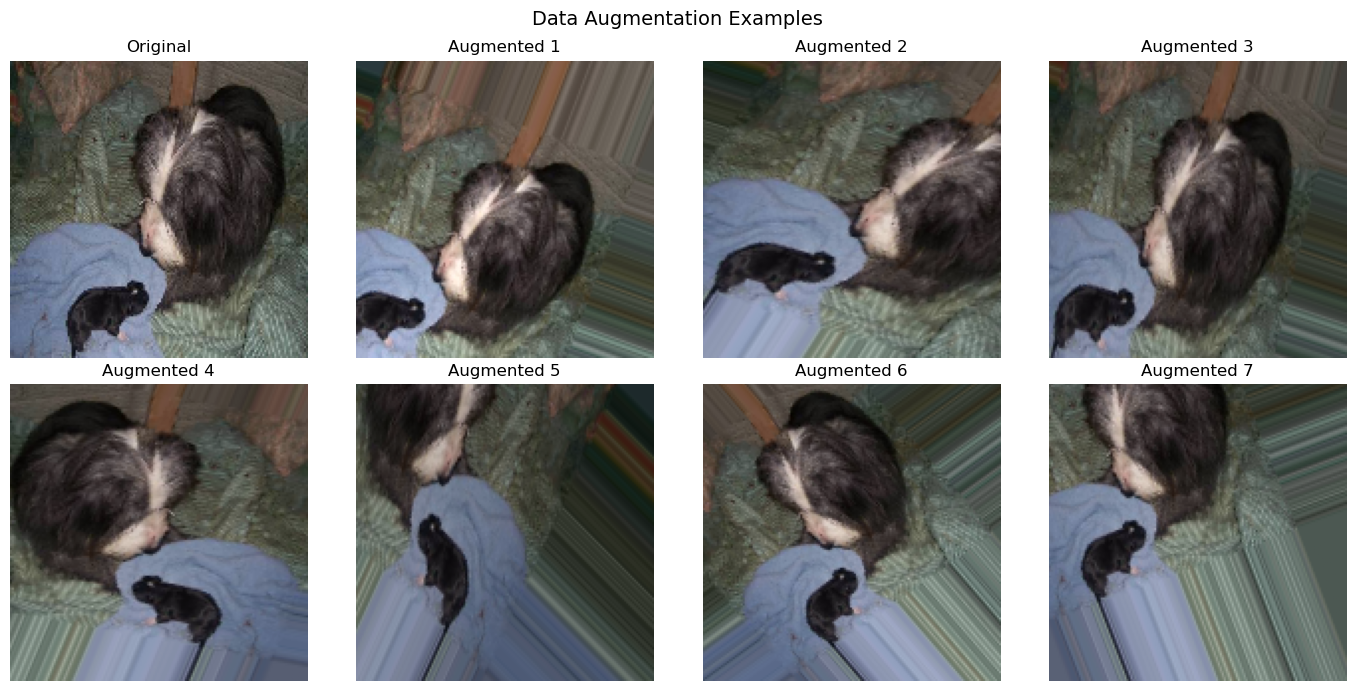

In [41]:
# Data Augmentation - ImageDataGenerator avec plus de transformations
augmented_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Visualiser les augmentations
sample_img = load_img(dog_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
sample_array = img_to_array(sample_img)
sample_array = sample_array.reshape((1,) + sample_array.shape)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
axes[0].imshow(load_img(dog_path, target_size=(IMG_HEIGHT, IMG_WIDTH)))
axes[0].set_title('Original')
axes[0].axis('off')

i = 1
for batch in augmented_generator.flow(sample_array, batch_size=1):
    axes[i].imshow(batch[0])
    axes[i].set_title(f'Augmented {i}')
    axes[i].axis('off')
    i += 1
    if i >= 8:
        break

plt.suptitle('Data Augmentation Examples', fontsize=14)
plt.tight_layout()
plt.show()

In [42]:
# Note sur la Data Augmentation
print("""Techniques de Data Augmentation utilisées :
- Rotation (jusqu'à 40°)
- Translation horizontale/verticale (30%)
- Shear (cisaillement)
- Zoom (30%)
- Flip horizontal
- Ajustement de luminosité

Ces techniques permettent de:
1. Augmenter artificiellement la taille du dataset
2. Améliorer la généralisation du modèle
3. Réduire l'overfitting
""")

Techniques de Data Augmentation utilisées :
- Rotation (jusqu'à 40°)
- Translation horizontale/verticale (30%)
- Shear (cisaillement)
- Zoom (30%)
- Flip horizontal
- Ajustement de luminosité

Ces techniques permettent de:
1. Augmenter artificiellement la taille du dataset
2. Améliorer la généralisation du modèle
3. Réduire l'overfitting



In [43]:
# La data augmentation a été appliquée dans l'ImageDataGenerator précédent
# Les améliorations seront visibles avec le Transfer Learning

# 11) Transfer learning

Utiliser la technique de transfer learning à partir d'un modèle open source qui vous semble pertinent. Justifier le choix du modèle ? 

Au final, votre accuracy s'est elle améliorée significativement ?

Vous êtes libre de structurer cette partie comme vous le jugez pertinent.

In [44]:
# Transfer Learning avec MobileNetV2
# Justification: MobileNetV2 est un modèle léger, rapide et efficace,
# pré-entrainé sur ImageNet (1000 classes incluant chiens et chats).
# Il est idéal pour le déploiement sur Streamlit grâce à sa taille réduite.

# Charger le modèle de base pré-entraîné (sans les couches de classification)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Geler les couches du modèle de base (on ne les entraine pas)
base_model.trainable = False

print(f"Nombre de couches dans MobileNetV2: {len(base_model.layers)}")
print(f"Couches gelées: {len(base_model.layers)}")

Nombre de couches dans MobileNetV2: 154
Couches gelées: 154


In [45]:
# Construire le modèle complet avec Transfer Learning
transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compiler le modèle
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [46]:
# Entrainer le modèle Transfer Learning
# Réinitialiser les générateurs
train_gen_tl = image_generator.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_gen_tl = val_image_generator.flow_from_directory(
    test_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Early stopping
early_stop_tl = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Entraînement
history_tl = transfer_model.fit(
    train_gen_tl,
    epochs=20,
    validation_data=val_gen_tl,
    callbacks=[early_stop_tl],
    verbose=1
)

Found 1996 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.8818 - loss: 0.2972 - val_accuracy: 0.9520 - val_loss: 0.1331
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9118 - loss: 0.2157 - val_accuracy: 0.9480 - val_loss: 0.1205
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9299 - loss: 0.1662 - val_accuracy: 0.9620 - val_loss: 0.1111
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9314 - loss: 0.1753 - val_accuracy: 0.9320 - val_loss: 0.1875
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9374 - loss: 0.1599 - val_accuracy: 0.9570 - val_loss: 0.1034
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9279 - loss: 0.1768 - val_accuracy: 0.9600 - val_loss: 0.1109
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.9364 - loss: 0.1495 - val_accuracy: 0.9610 - val_loss: 0.1080
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━

# 12) Déploiement

À partir du modèle définitif que vous aurez construit et sauvegardé sur Keras, vous devez créer une webapp où l'utilisateur peut se connecter à l'URL, charger une image de chien ou chat et obtenir en retour la prédiction du modèle.

Stack recommandé: streamlit pour le développement de la webapp & render pour le hosting

In [50]:
# evaluation du modèle Transfer Learning
val_gen_tl.reset()
y_pred_proba_tl = transfer_model.predict(val_gen_tl, verbose=1)
y_pred_class_tl = (y_pred_proba_tl > 0.5).astype(int).flatten()
y_test_tl = val_gen_tl.classes

# Accuracy
accuracy_tl = accuracy_score(y_test_tl, y_pred_class_tl)
print(f"\n=== Accuracy Transfer Learning: {accuracy_tl * 100:.2f}% ===")
print(f"=== Amélioration vs CNN from scratch: {(accuracy_tl - accuracy) * 100:.2f}% ===")

# Classification report
print("\n=== Classification Report (Transfer Learning) ===")
print(classification_report(y_test_tl, y_pred_class_tl, target_names=['Cat', 'Dog']))

32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 840ms/step

=== Accuracy Transfer Learning: 96.20% ===
=== Amélioration vs CNN from scratch: 17.70% ===

=== Classification Report (Transfer Learning) ===
              precision    recall  f1-score   support

         Cat       0.97      0.95      0.96       500
         Dog       0.95      0.97      0.96       500

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



In [51]:
# Sauvegarder le modèle final pour le déploiement Streamlit
MODEL_PATH = r'C:\Users\nmellouki\Downloads\MSDE7\M06_Deep_Learning\final_project\cats_dogs_mobilenetv2.keras'
transfer_model.save(MODEL_PATH)
print(f" Modèle sauvegardé: {MODEL_PATH}")

 Modèle sauvegardé: C:\Users\nmellouki\Downloads\MSDE7\M06_Deep_Learning\final_project\cats_dogs_mobilenetv2.keras


In [56]:
# Conversion du modèle Keras vers ONNX pour le déploiement
# (ONNX est compatible avec Python 3.14 sur Streamlit Cloud, contrairement à TensorFlow)

import subprocess

# Installer tf2onnx
subprocess.run(['pip', 'install', 'tf2onnx', 'onnxruntime', '-q'], check=True)

# Convertir le modèle Keras en ONNX
ONNX_PATH = MODEL_PATH.replace('.keras', '.onnx').replace('mobilenetv2', 'model')
result = subprocess.run([
    'python', '-m', 'tf2onnx.convert',
    '--keras', MODEL_PATH,
    '--output', ONNX_PATH,
    '--opset', '13'
], capture_output=True, text=True)

print(result.stdout)
if result.returncode == 0:
    print(f"Modèle ONNX sauvegardé: {ONNX_PATH}")
else:
    print(f"Erreur: {result.stderr}")


Modèle ONNX sauvegardé: C:\Users\nmellouki\Downloads\MSDE7\M06_Deep_Learning\final_project\cats_dogs_model.onnx


In [53]:
# Instructions de déploiement sur Streamlit Cloud
print("""DEPLOIEMENT SUR STREAMLIT CLOUD :

1. Modèle entrainé et sauvegardé: cats_dogs_mobilenetv2.keras

2. CONVERSION ONNX (pour compatibilité Python 3.14 sur Streamlit Cloud):
   - TensorFlow n'est pas disponible pour Python 3.14
   - Conversion du modèle Keras vers ONNX avec tf2onnx:
     python -m tf2onnx.convert --keras cats_dogs_mobilenetv2.keras --output cats_dogs_model.onnx --opset 13
   - Fichier déployé: cats_dogs_model.onnx

3. Fichiers sur GitHub (repo: melloukainabil/Projet_DeepL):
   - app.py (utilise onnxruntime)
   - requirements.txt (streamlit, onnxruntime, numpy, Pillow)
   - cats_dogs_model.onnx

4. Déploiement sur Streamlit Cloud""")

# URL de l'application Streamlit
APP_URL = "https://projetdeepl-mellouki.streamlit.app/"
print(f"URL: {APP_URL}")

DEPLOIEMENT SUR STREAMLIT CLOUD :

1. Modèle entraîné et sauvegardé: cats_dogs_mobilenetv2.keras

2. CONVERSION ONNX (pour compatibilité Python 3.14 sur Streamlit Cloud):
   - TensorFlow n'est pas disponible pour Python 3.14
   - Conversion du modèle Keras vers ONNX avec tf2onnx:
     python -m tf2onnx.convert --keras cats_dogs_mobilenetv2.keras --output cats_dogs_model.onnx --opset 13
   - Fichier déployé: cats_dogs_model.onnx

3. Fichiers sur GitHub (repo: melloukainabil/Projet_DeepL):
   - app.py (utilise onnxruntime)
   - requirements.txt (streamlit, onnxruntime, numpy, Pillow)
   - cats_dogs_model.onnx

4. Déploiement sur Streamlit Cloud
URL: https://projetdeepl-mellouki.streamlit.app/
